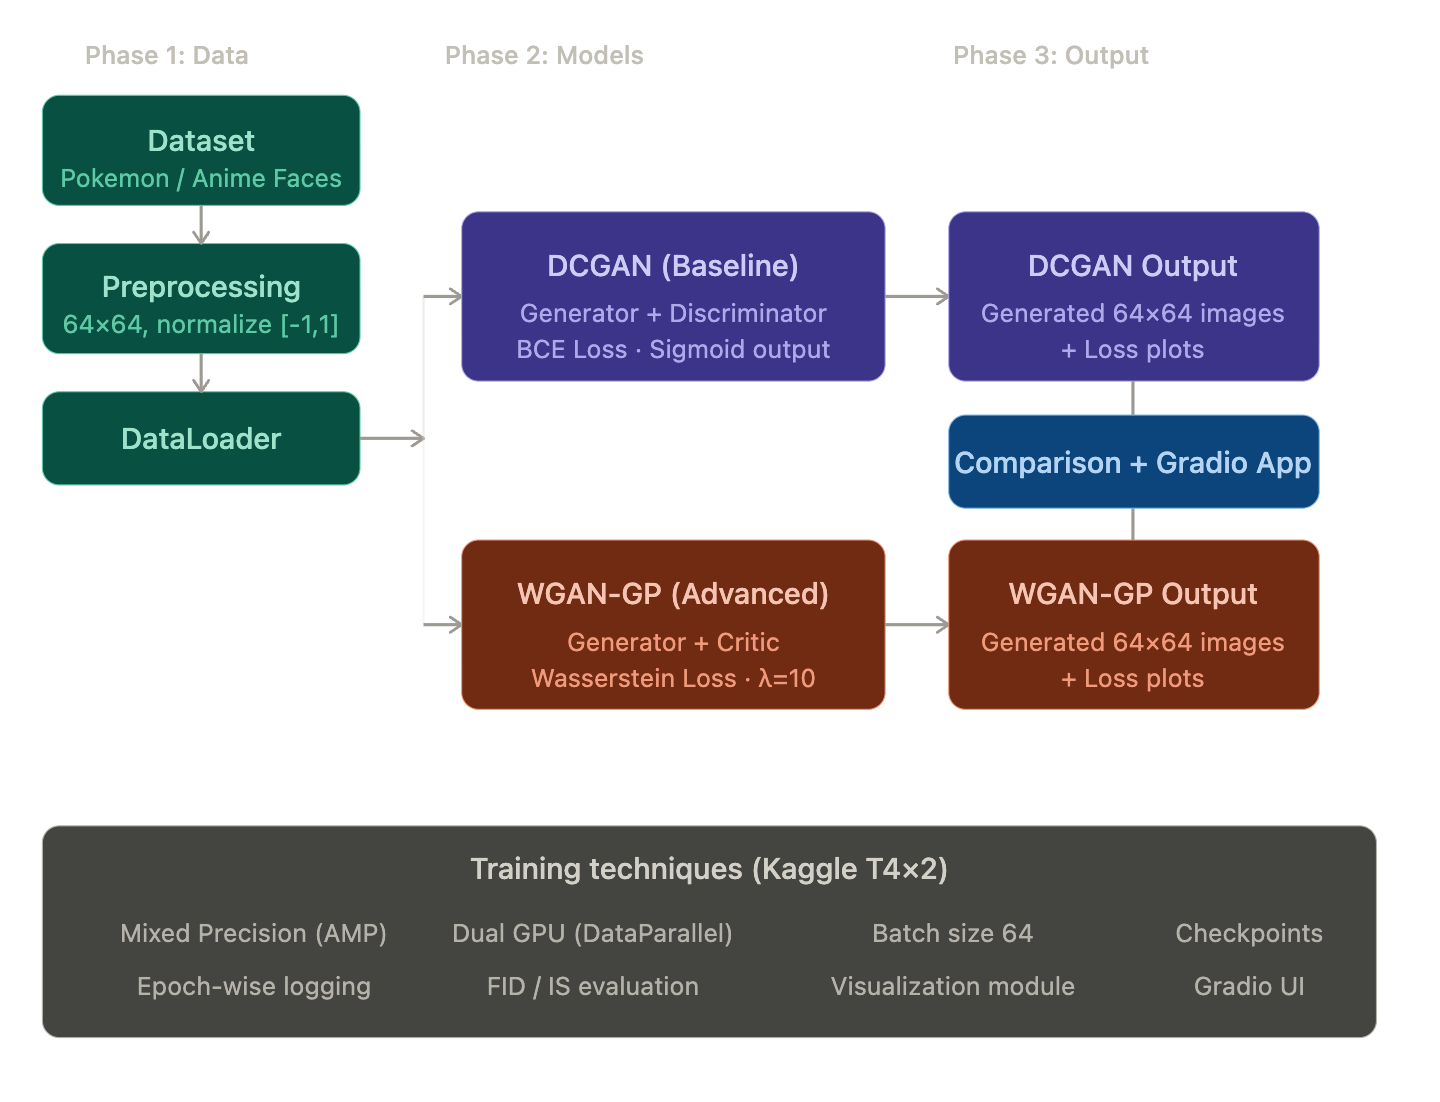](http://)

In [14]:
import os, random, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils as vutils
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
 
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
 
# Device setup — uses both GPUs if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Device: {device} | GPUs available: {num_gpus}")
for i in range(num_gpus):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
 
# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE   = 64
NC         = 3          # number of image channels
NZ         = 100        # noise vector dimension
NGF        = 64         # generator feature map base
NDF        = 64         # discriminator feature map base
BATCH_SIZE = 64
LR         = 0.0002
BETA1      = 0.5
BETA2      = 0.999
N_EPOCHS_DCGAN  = 50
N_EPOCHS_WGANGP = 50
CRITIC_ITERS    = 5     # WGAN-GP: critic updates per generator update
LAMBDA_GP       = 10    # WGAN-GP: gradient penalty coefficient
SAVE_EVERY      = 10    # save checkpoint every N epochs
N_SAMPLES_VIZ   = 64    # number of samples for visualization
 
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("outputs",      exist_ok=True)
os.makedirs("logs",         exist_ok=True)
 
print("Setup complete.")

Device: cuda | GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Setup complete.


Found 33887 images in: /kaggle/input/datasets/jackemartin/pokemon-sprites/pokemon_images
Dataset     : pokemon
Total images: 10000
Batches     : 156


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


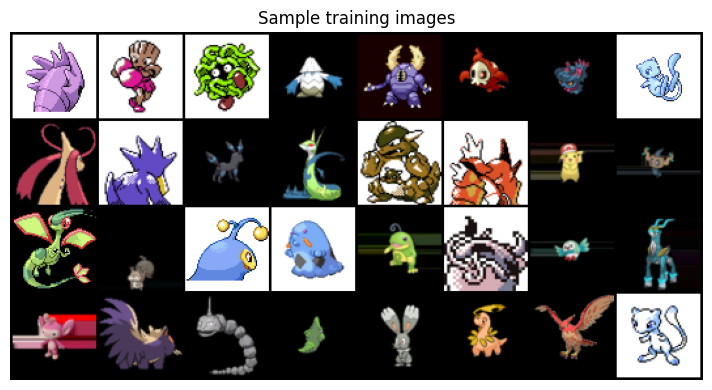

In [15]:
# ============================================================
# CELL 2 — Data Preparation (Custom Dataset for flat image dirs)
# ============================================================
from torch.utils.data import Dataset
from glob import glob

class FlatImageDataset(Dataset):
    """
    Loads images from a flat directory (no class subfolders).
    Supports recursive search for nested folders.
    """
    def __init__(self, root, transform=None):
        self.transform = transform
        # Recursively find all jpg/png/jpeg images
        self.image_paths = (
            glob(os.path.join(root, "**", "*.jpg"),  recursive=True) +
            glob(os.path.join(root, "**", "*.jpeg"), recursive=True) +
            glob(os.path.join(root, "**", "*.png"),  recursive=True)
        )
        self.image_paths = sorted(self.image_paths)
        print(f"Found {len(self.image_paths)} images in: {root}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            # Skip corrupted images — return a black image instead
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, 0   # dummy label to match DataLoader convention

# ── Choose dataset ───────────────────────────────────────────
# Set DATASET to "pokemon" or "anime"
DATASET = "pokemon"   # change to "anime" if preferred

DATASET_PATHS = {
    "pokemon": "/kaggle/input/datasets/jackemartin/pokemon-sprites/pokemon_images",
    "anime"  : "/kaggle/input/datasets/soumikrakshit/anime-faces/data/data",
}
DATA_ROOT = DATASET_PATHS[DATASET]

# ── Transforms ───────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5]),   # normalize to [-1, 1]
])

# ── Load dataset ─────────────────────────────────────────────
full_dataset = FlatImageDataset(root=DATA_ROOT, transform=transform)

# Optional subset to fit GPU memory (set MAX_SAMPLES=None to use all)
MAX_SAMPLES = 10000
if MAX_SAMPLES and len(full_dataset) > MAX_SAMPLES:
    indices = random.sample(range(len(full_dataset)), MAX_SAMPLES)
    dataset = Subset(full_dataset, indices)
else:
    dataset = full_dataset

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
)

print(f"Dataset     : {DATASET}")
print(f"Total images: {len(dataset)}")
print(f"Batches     : {len(dataloader)}")

# ── Visualize a sample batch ──────────────────────────────────
real_batch = next(iter(dataloader))
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")
ax.set_title("Sample training images", fontsize=12)
grid = vutils.make_grid(real_batch[0][:32], nrow=8, normalize=True, padding=2)
ax.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.tight_layout()
plt.savefig("outputs/sample_training_images.png", dpi=150)
plt.show()

In [17]:
def weights_init(m):
    """Apply DCGAN paper weight initialization."""
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [18]:
class DCGANGenerator(nn.Module):
    """
    Generator: maps noise z (NZ,) → RGB image (3, 64, 64).
    Uses Transposed Convolutions + BatchNorm + ReLU + Tanh.
    """
    def __init__(self, nz=NZ, ngf=NGF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            # input: z of shape (nz, 1, 1)
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # (ngf*8) × 4 × 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4) × 8 × 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2) × 16 × 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # (ngf) × 32 × 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
            # (nc) × 64 × 64
        )
 
    def forward(self, z):
        return self.main(z)
 
 
class DCGANDiscriminator(nn.Module):
    """
    Discriminator: maps image (3, 64, 64) → real/fake probability in [0,1].
    Uses Convolutions + LeakyReLU + BatchNorm + Sigmoid.
    """
    def __init__(self, ndf=NDF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            # input: (nc) × 64 × 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf) × 32 × 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) × 16 × 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) × 8 × 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8) × 4 × 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
            # scalar output
        )
 
    def forward(self, x):
        return self.main(x).view(-1)
 
 
# Instantiate & wrap for multi-GPU
netG_dcgan = DCGANGenerator(NZ, NGF, NC).to(device)
netD_dcgan = DCGANDiscriminator(NDF, NC).to(device)
 
if num_gpus > 1:
    netG_dcgan = nn.DataParallel(netG_dcgan)
    netD_dcgan = nn.DataParallel(netD_dcgan)
 
netG_dcgan.apply(weights_init)
netD_dcgan.apply(weights_init)
 
print("DCGAN Generator:")
print(netG_dcgan)
print("\nDCGAN Discriminator:")
print(netD_dcgan)
 
total_params_G = sum(p.numel() for p in netG_dcgan.parameters())
total_params_D = sum(p.numel() for p in netD_dcgan.parameters())
print(f"\nGenerator params:     {total_params_G:,}")
print(f"Discriminator params: {total_params_D:,}")

DCGAN Generator:
DataParallel(
  (module): DCGANGenerator(
    (main): Sequential(
      (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU(inplace=True)
      (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU(inplace=True)
      (12): ConvTranspose2d(64, 3, kernel_siz

In [19]:
class WGANGPGenerator(nn.Module):
    """Same architecture as DCGAN Generator — shared backbone."""
    def __init__(self, nz=NZ, ngf=NGF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
 
    def forward(self, z):
        return self.main(z)
 
 
class WGANGPCritic(nn.Module):
    """
    Critic (not Discriminator): no Sigmoid output, no BatchNorm.
    Uses LayerNorm-style (or no norm) for WGAN-GP compatibility.
    Note: BatchNorm is incompatible with gradient penalty computation.
    """
    def __init__(self, ndf=NDF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            # input: (nc) × 64 × 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf) × 32 × 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) × 16 × 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) × 8 × 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8) × 4 × 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            # NO Sigmoid — outputs raw critic score
        )
 
    def forward(self, x):
        return self.main(x).view(-1)
 
 
def compute_gradient_penalty(critic, real_imgs, fake_imgs, device):
    """
    Gradient penalty for WGAN-GP.
    Enforces the 1-Lipschitz constraint by penalizing deviations
    from unit gradient norm at interpolated points.
    """
    B = real_imgs.size(0)
    # Random interpolation coefficient α ~ Uniform[0,1]
    alpha = torch.rand(B, 1, 1, 1, device=device).expand_as(real_imgs)
    # Interpolated samples
    interpolated = (alpha * real_imgs + (1 - alpha) * fake_imgs).requires_grad_(True)
    # Critic score at interpolated points
    critic_interpolated = critic(interpolated)
    # Compute gradients of critic scores w.r.t. interpolated inputs
    gradients = torch.autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    # Flatten gradients and compute L2 norm
    gradients = gradients.view(B, -1)
    grad_norm = gradients.norm(2, dim=1)
    # Penalty: (||∇|| - 1)²
    penalty = ((grad_norm - 1) ** 2).mean()
    return penalty
 
 
# Instantiate & wrap for multi-GPU
netG_wgan = WGANGPGenerator(NZ, NGF, NC).to(device)
netC_wgan = WGANGPCritic(NDF, NC).to(device)
 
if num_gpus > 1:
    netG_wgan = nn.DataParallel(netG_wgan)
    netC_wgan = nn.DataParallel(netC_wgan)
 
netG_wgan.apply(weights_init)
netC_wgan.apply(weights_init)
 
print("WGAN-GP Generator and Critic instantiated.")


WGAN-GP Generator and Critic instantiated.


In [20]:
def generate_fixed_noise(n=N_SAMPLES_VIZ, nz=NZ):
    """Fixed noise for consistent visualization across epochs."""
    return torch.randn(n, nz, 1, 1, device=device)
 
fixed_noise = generate_fixed_noise()
 
def save_checkpoint(netG, netD, optG, optD, epoch, losses, name):
    path = f"checkpoints/{name}_epoch{epoch:03d}.pt"
    torch.save({
        "epoch"  : epoch,
        "netG"   : netG.state_dict(),
        "netD"   : netD.state_dict(),
        "optG"   : optG.state_dict(),
        "optD"   : optD.state_dict(),
        "losses" : losses,
    }, path)
    print(f"  ✓ Checkpoint saved: {path}")
 
def save_generated_images(netG, noise, epoch, name, nrow=8):
    netG.eval()
    with torch.no_grad():
        fake = netG(noise).detach().cpu()
    img_grid = vutils.make_grid(fake[:64], nrow=nrow, normalize=True, padding=2)
    path = f"outputs/{name}_epoch{epoch:03d}.png"
    vutils.save_image(img_grid, path)
    netG.train()
    return img_grid
 
def plot_losses(G_losses, D_losses, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(G_losses, label="Generator Loss", color="#8B5CF6", linewidth=1.2)
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} — Generator Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(D_losses, label="Discriminator/Critic Loss", color="#EF4444", linewidth=1.2)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Loss")
    axes[1].set_title(f"{title} — Discriminator/Critic Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

  Starting DCGAN Training


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[DCGAN] Epoch   1/50 | G: 13.8076 | D: 0.3629 | Elapsed: 0.4m


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[DCGAN] Epoch   2/50 | G: 4.5429 | D: 0.3905 | Elapsed: 0.8m


...

[DCGAN] Epoch  48/50 | G: 4.3013 | D: 0.3334 | Elapsed: 17.6m


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[DCGAN] Epoch  49/50 | G: 4.2459 | D: 0.3745 | Elapsed: 18.0m


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[DCGAN] Epoch  50/50 | G: 4.4898 | D: 0.2588 | Elapsed: 18.3m
  ✓ Checkpoint saved: checkpoints/dcgan_epoch050.pt

DCGAN training complete in 18.3m


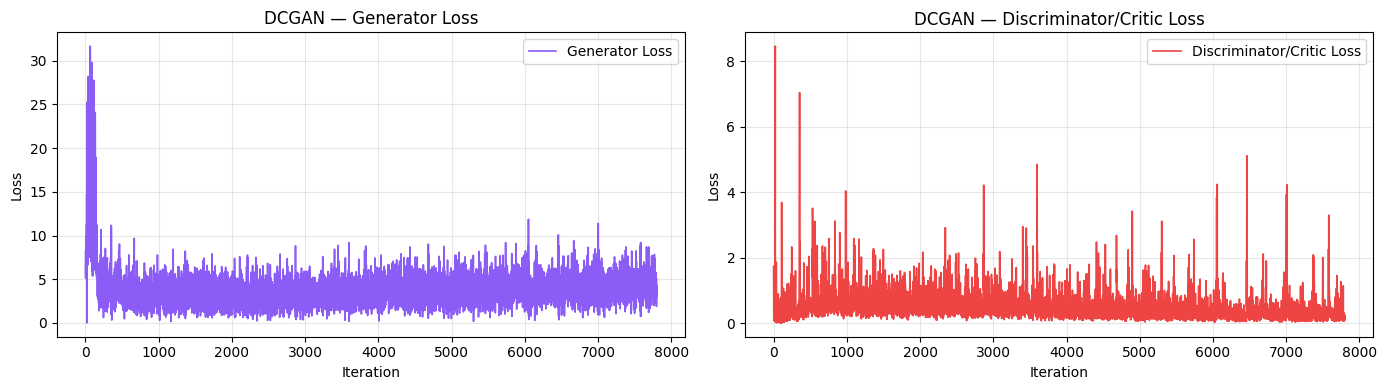

In [21]:
# ============================================================
# CELL 7 — DCGAN Training Loop (fixed)
# ============================================================
def train_dcgan(netG, netD, dataloader, n_epochs=N_EPOCHS_DCGAN):
    # BCEWithLogitsLoss is AMP-safe (combines sigmoid + BCE internally)
    criterion = nn.BCEWithLogitsLoss()

    optimG = torch.optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, BETA2))
    optimD = torch.optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, BETA2))

    # Updated GradScaler syntax for newer PyTorch
    scalerG = torch.amp.GradScaler('cuda')
    scalerD = torch.amp.GradScaler('cuda')

    G_losses, D_losses = [], []

    print("=" * 55)
    print("  Starting DCGAN Training")
    print("=" * 55)
    t0 = time.time()

    for epoch in range(1, n_epochs + 1):
        netG.train(); netD.train()
        epoch_G, epoch_D = [], []

        for i, (real_imgs, _) in enumerate(dataloader):
            real_imgs = real_imgs.to(device, non_blocking=True)
            B = real_imgs.size(0)
            real_label = torch.ones(B,  device=device)
            fake_label = torch.zeros(B, device=device)

            # ─── Train Discriminator ─────────────────────────
            optimD.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                out_real  = netD(real_imgs)
                loss_real = criterion(out_real, real_label)
                noise     = torch.randn(B, NZ, 1, 1, device=device)
                fake_imgs = netG(noise).detach()
                out_fake  = netD(fake_imgs)
                loss_fake = criterion(out_fake, fake_label)
                loss_D    = loss_real + loss_fake

            scalerD.scale(loss_D).backward()
            scalerD.step(optimD)
            scalerD.update()

            # ─── Train Generator ─────────────────────────────
            optimG.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                noise     = torch.randn(B, NZ, 1, 1, device=device)
                fake_imgs = netG(noise)
                out_fake  = netD(fake_imgs)
                loss_G    = criterion(out_fake, real_label)

            scalerG.scale(loss_G).backward()
            scalerG.step(optimG)
            scalerG.update()

            G_losses.append(loss_G.item())
            D_losses.append(loss_D.item())
            epoch_G.append(loss_G.item())
            epoch_D.append(loss_D.item())

        elapsed = (time.time() - t0) / 60
        print(f"[DCGAN] Epoch {epoch:3d}/{n_epochs} | "
              f"G: {np.mean(epoch_G):.4f} | "
              f"D: {np.mean(epoch_D):.4f} | "
              f"Elapsed: {elapsed:.1f}m")

        if epoch % 5 == 0 or epoch == n_epochs:
            save_generated_images(netG, fixed_noise, epoch, "dcgan")
        if epoch % SAVE_EVERY == 0 or epoch == n_epochs:
            save_checkpoint(netG, netD, optimG, optimD, epoch,
                            {"G": G_losses, "D": D_losses}, "dcgan")

    print(f"\nDCGAN training complete in {(time.time()-t0)/60:.1f}m")
    plot_losses(G_losses, D_losses, "DCGAN", "logs/dcgan_losses.png")
    return G_losses, D_losses


# Also remove Sigmoid from the Discriminator — BCEWithLogitsLoss expects raw logits
# Go back and redefine DCGANDiscriminator with the Sigmoid removed:
class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf=NDF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            # NO Sigmoid here — BCEWithLogitsLoss applies it internally
        )

    def forward(self, x):
        return self.main(x).view(-1)

# Re-instantiate with fixed architecture
netD_dcgan = DCGANDiscriminator(NDF, NC).to(device)
if num_gpus > 1:
    netD_dcgan = nn.DataParallel(netD_dcgan)
netD_dcgan.apply(weights_init)

# Now run training
dcgan_G_losses, dcgan_D_losses = train_dcgan(netG_dcgan, netD_dcgan, dataloader)

  Starting WGAN-GP Training


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[WGAN-GP] Epoch   1/50 | G: 5.1086 | C: 12.0257 | Elapsed: 0.2m


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[WGAN-GP] Epoch   2/50 | G: 19.5108 | C: -16.1444 | Elapsed: 0.5m


...

[WGAN-GP] Epoch  48/50 | G: 41.3482 | C: -16.2938 | Elapsed: 12.4m


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[WGAN-GP] Epoch  49/50 | G: 47.8876 | C: -16.6094 | Elapsed: 12.6m


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[WGAN-GP] Epoch  50/50 | G: 46.3355 | C: -16.5099 | Elapsed: 12.9m
  ✓ Checkpoint saved: checkpoints/wgangp_epoch050.pt

WGAN-GP training complete in 12.9m


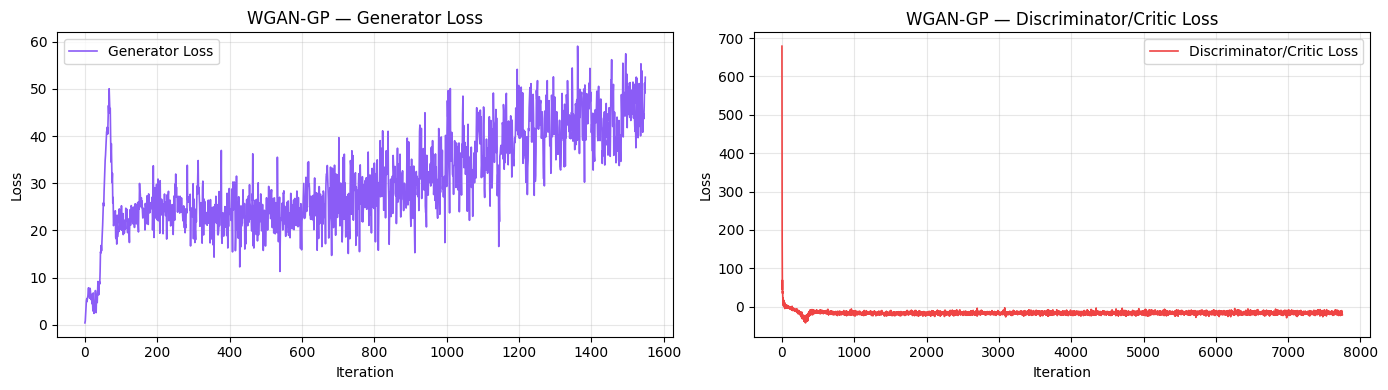

In [22]:
def train_wgangp(netG, netC, dataloader, n_epochs=N_EPOCHS_WGANGP):
    optimG = torch.optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, BETA2))
    optimC = torch.optim.Adam(netC.parameters(), lr=LR, betas=(BETA1, BETA2))
 
    G_losses, C_losses = [], []
 
    print("=" * 55)
    print("  Starting WGAN-GP Training")
    print("=" * 55)
    t0 = time.time()
 
    for epoch in range(1, n_epochs + 1):
        netG.train(); netC.train()
        epoch_G, epoch_C = [], []
        data_iter = iter(dataloader)
 
        # Number of generator steps this epoch
        n_gen_steps = len(dataloader) // CRITIC_ITERS
 
        for _ in range(n_gen_steps):
            # ─── Train Critic (CRITIC_ITERS times) ──────────
            for _ in range(CRITIC_ITERS):
                try:
                    real_imgs, _ = next(data_iter)
                except StopIteration:
                    data_iter = iter(dataloader)
                    real_imgs, _ = next(data_iter)
 
                real_imgs = real_imgs.to(device, non_blocking=True)
                B = real_imgs.size(0)
 
                optimC.zero_grad(set_to_none=True)
 
                noise     = torch.randn(B, NZ, 1, 1, device=device)
                fake_imgs = netG(noise).detach()
 
                # Wasserstein loss: maximize E[C(real)] - E[C(fake)]
                # i.e. minimize E[C(fake)] - E[C(real)]
                c_real    = netC(real_imgs).mean()
                c_fake    = netC(fake_imgs).mean()
                gp        = compute_gradient_penalty(netC, real_imgs.data, fake_imgs.data, device)
                loss_C    = c_fake - c_real + LAMBDA_GP * gp
 
                loss_C.backward()
                optimC.step()
 
                C_losses.append(loss_C.item())
                epoch_C.append(loss_C.item())
 
            # ─── Train Generator (once) ─────────────────────
            optimG.zero_grad(set_to_none=True)
            noise     = torch.randn(B, NZ, 1, 1, device=device)
            fake_imgs = netG(noise)
            # Generator maximizes E[C(fake)] → minimize -E[C(fake)]
            loss_G    = -netC(fake_imgs).mean()
 
            loss_G.backward()
            optimG.step()
 
            G_losses.append(loss_G.item())
            epoch_G.append(loss_G.item())
 
        elapsed = (time.time() - t0) / 60
        print(f"[WGAN-GP] Epoch {epoch:3d}/{n_epochs} | "
              f"G: {np.mean(epoch_G):.4f} | "
              f"C: {np.mean(epoch_C):.4f} | "
              f"Elapsed: {elapsed:.1f}m")
 
        if epoch % 5 == 0 or epoch == n_epochs:
            save_generated_images(netG, fixed_noise, epoch, "wgangp")
        if epoch % SAVE_EVERY == 0 or epoch == n_epochs:
            save_checkpoint(netG, netC, optimG, optimC, epoch,
                            {"G": G_losses, "C": C_losses}, "wgangp")
 
    print(f"\nWGAN-GP training complete in {(time.time()-t0)/60:.1f}m")
    plot_losses(G_losses, C_losses, "WGAN-GP", "logs/wgangp_losses.png")
    return G_losses, C_losses
 
 
# Run WGAN-GP training
wgan_G_losses, wgan_C_losses = train_wgangp(netG_wgan, netC_wgan, dataloader)

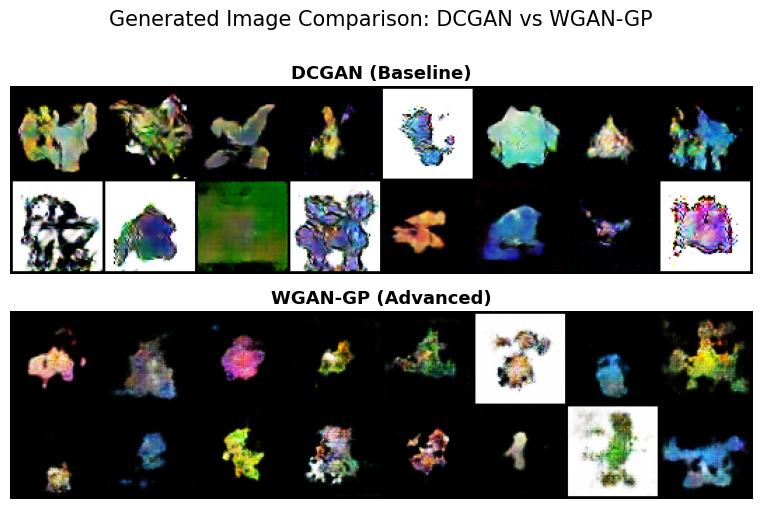

Comparison saved to outputs/comparison_dcgan_vs_wgangp.png


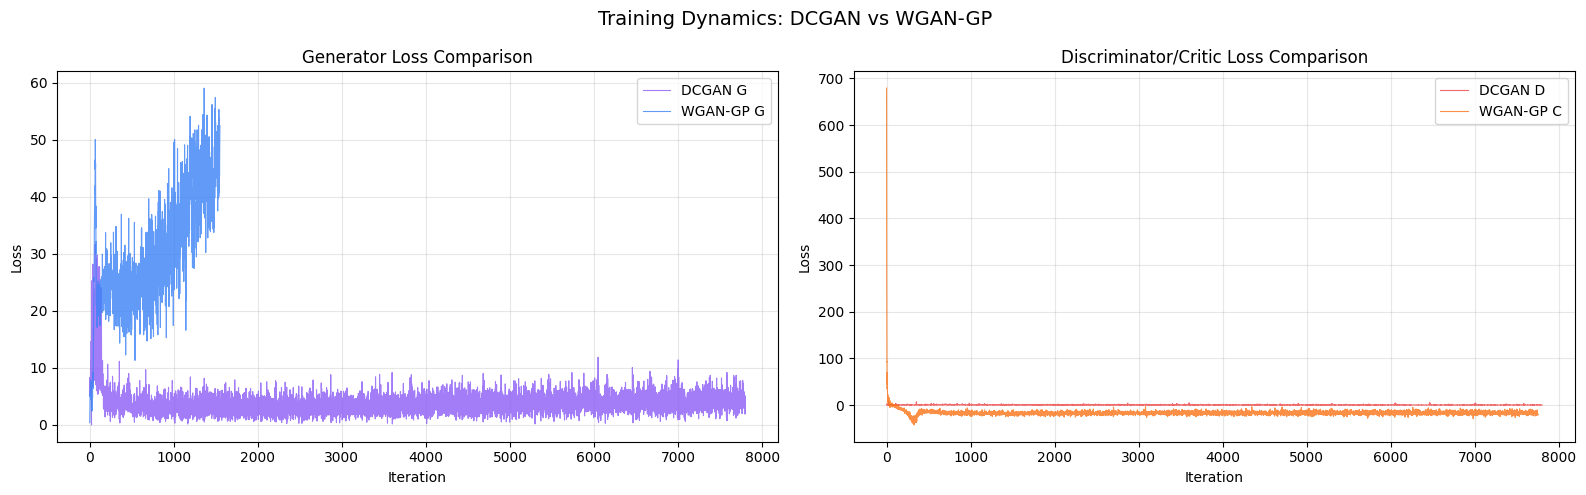

In [23]:
def visualize_comparison(netG_dcgan, netG_wgan, noise, n=16, nrow=8):
    """Side-by-side comparison of DCGAN vs WGAN-GP outputs."""
    for net in [netG_dcgan, netG_wgan]:
        net.eval()
 
    with torch.no_grad():
        fake_dcgan = netG_dcgan(noise[:n]).detach().cpu()
        fake_wgan  = netG_wgan(noise[:n]).detach().cpu()
 
    fig, axes = plt.subplots(2, 1, figsize=(16, 5))
    for ax, imgs, label in zip(
        axes,
        [fake_dcgan, fake_wgan],
        ["DCGAN (Baseline)", "WGAN-GP (Advanced)"]
    ):
        grid = vutils.make_grid(imgs, nrow=nrow, normalize=True, padding=2)
        ax.imshow(grid.permute(1, 2, 0).numpy())
        ax.set_title(label, fontsize=13, fontweight="bold")
        ax.axis("off")
 
    plt.suptitle("Generated Image Comparison: DCGAN vs WGAN-GP", fontsize=15, y=1.01)
    plt.tight_layout()
    plt.savefig("outputs/comparison_dcgan_vs_wgangp.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Comparison saved to outputs/comparison_dcgan_vs_wgangp.png")
 
 
def plot_combined_losses(dcgan_G, dcgan_D, wgan_G, wgan_C):
    """Overlay loss curves for both models on the same axes."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
    axes[0].plot(dcgan_G, alpha=0.8, label="DCGAN G",   color="#8B5CF6", linewidth=0.8)
    axes[0].plot(wgan_G,  alpha=0.8, label="WGAN-GP G", color="#3B82F6", linewidth=0.8)
    axes[0].set_title("Generator Loss Comparison")
    axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)
 
    axes[1].plot(dcgan_D, alpha=0.8, label="DCGAN D",    color="#EF4444", linewidth=0.8)
    axes[1].plot(wgan_C,  alpha=0.8, label="WGAN-GP C",  color="#F97316", linewidth=0.8)
    axes[1].set_title("Discriminator/Critic Loss Comparison")
    axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(alpha=0.3)
 
    plt.suptitle("Training Dynamics: DCGAN vs WGAN-GP", fontsize=14)
    plt.tight_layout()
    plt.savefig("logs/combined_loss_comparison.png", dpi=150)
    plt.show()
 
 
visualize_comparison(netG_dcgan, netG_wgan, fixed_noise)
plot_combined_losses(dcgan_G_losses, dcgan_D_losses, wgan_G_losses, wgan_C_losses)

In [26]:
!pip install pytorch-fid -q

[FID] Saving 2048 real images...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[FID] Generating 2048 fake images...
[FID] Computing FID score for dcgan...
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 253MB/s]
100%|██████████| 32/32 [00:08<00:00,  3.97it/s]


[FID] DCGAN FID Score: 137.9105
[FID] Saving 2048 real images...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[FID] Generating 2048 fake images...
[FID] Computing FID score for wgangp...


100%|██████████| 32/32 [00:08<00:00,  3.95it/s]


[FID] WGANGP FID Score: 163.4009

  DCGAN   FID: 137.9105
  WGAN-GP FID: 163.4009
  Winner:      DCGAN (lower is better)


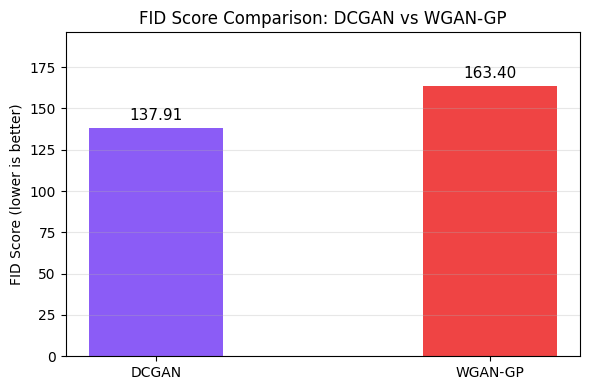

In [27]:
import shutil
from pytorch_fid import fid_score

def compute_fid(netG, real_dataloader, n_samples=2048, name="model"):
    real_dir = f"/tmp/fid_real_{name}"
    fake_dir = f"/tmp/fid_fake_{name}"
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    # ── Save real images ──────────────────────────────────────
    print(f"[FID] Saving {n_samples} real images...")
    count = 0
    for imgs, _ in real_dataloader:
        for img in imgs:
            vutils.save_image(img, f"{real_dir}/{count:05d}.png", normalize=True)
            count += 1
            if count >= n_samples:
                break
        if count >= n_samples:
            break

    # ── Save fake images ──────────────────────────────────────
    print(f"[FID] Generating {n_samples} fake images...")
    netG.eval()
    count = 0
    with torch.no_grad():
        while count < n_samples:
            batch = min(64, n_samples - count)
            z = torch.randn(batch, NZ, 1, 1, device=device)
            fake = netG(z).detach().cpu()
            for img in fake:
                vutils.save_image(img, f"{fake_dir}/{count:05d}.png", normalize=True)
                count += 1

    # ── Compute FID ───────────────────────────────────────────
    print(f"[FID] Computing FID score for {name}...")
    fid = fid_score.calculate_fid_given_paths(
        [real_dir, fake_dir],
        batch_size=64,
        device=device,
        dims=2048,
    )
    print(f"[FID] {name.upper()} FID Score: {fid:.4f}")

    # ── Cleanup temp dirs ─────────────────────────────────────
    shutil.rmtree(real_dir)
    shutil.rmtree(fake_dir)

    return fid


# Compute for both models
fid_dcgan = compute_fid(netG_dcgan, dataloader, n_samples=2048, name="dcgan")
fid_wgan  = compute_fid(netG_wgan,  dataloader, n_samples=2048, name="wgangp")

# ── Summary ───────────────────────────────────────────────────
print("\n" + "=" * 40)
print(f"  DCGAN   FID: {fid_dcgan:.4f}")
print(f"  WGAN-GP FID: {fid_wgan:.4f}")
print(f"  Winner:      {'WGAN-GP' if fid_wgan < fid_dcgan else 'DCGAN'} (lower is better)")
print("=" * 40)

# ── Bar chart comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["DCGAN", "WGAN-GP"], [fid_dcgan, fid_wgan],
              color=["#8B5CF6", "#EF4444"], width=0.4)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=11)
ax.set_ylabel("FID Score (lower is better)")
ax.set_title("FID Score Comparison: DCGAN vs WGAN-GP")
ax.set_ylim(0, max(fid_dcgan, fid_wgan) * 1.2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("logs/fid_comparison.png", dpi=150)
plt.show()

In [30]:
!pip install gradio -q

In [35]:
import gradio as gr

def generate_images_gradio(model_choice: str, n_samples: int, seed: int):
    torch.manual_seed(int(seed))
    n = max(1, min(int(n_samples), 64))
    z = torch.randn(n, NZ, 1, 1, device=device)

    netG_dcgan.eval()
    netG_wgan.eval()

    with torch.no_grad():
        if model_choice == "DCGAN":
            fake = netG_dcgan(z).detach().cpu()
            grid = vutils.make_grid(fake, nrow=8, normalize=True, padding=2)
            img_np = (grid.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            return Image.fromarray(img_np), None

        elif model_choice == "WGAN-GP":
            fake = netG_wgan(z).detach().cpu()
            grid = vutils.make_grid(fake, nrow=8, normalize=True, padding=2)
            img_np = (grid.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            return None, Image.fromarray(img_np)

        else:  # Both
            fake_d = netG_dcgan(z).detach().cpu()
            fake_w = netG_wgan(z).detach().cpu()
            grid_d = vutils.make_grid(fake_d, nrow=8, normalize=True, padding=2)
            grid_w = vutils.make_grid(fake_w, nrow=8, normalize=True, padding=2)
            img_d = (grid_d.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            img_w = (grid_w.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            return Image.fromarray(img_d), Image.fromarray(img_w)


def get_loss_plot():
    path = "logs/combined_loss_comparison.png"
    if os.path.exists(path):
        return Image.open(path)
    path2 = "logs/dcgan_losses.png"
    if os.path.exists(path2):
        return Image.open(path2)
    return None


def get_fid_plot():
    path = "logs/fid_comparison.png"
    if os.path.exists(path):
        return Image.open(path)
    return None


with gr.Blocks(title="GAN Image Generator") as demo:
    gr.Markdown(
        "# GAN Image Generator\n"
        "## DCGAN (Baseline) vs WGAN-GP (Advanced)"
    )

    with gr.Row():
        with gr.Column(scale=1):
            model_choice = gr.Radio(
                choices=["DCGAN", "WGAN-GP", "Both"],
                value="Both",
                label="Select Model",
            )
            n_samples = gr.Slider(
                minimum=8, maximum=64, step=8, value=16,
                label="Number of samples",
            )
            seed = gr.Number(value=42, label="Random seed", precision=0)
            btn_generate = gr.Button("Generate Images", variant="primary")

        with gr.Column(scale=2):
            gr.Markdown("### DCGAN output")
            out_dcgan = gr.Image(label="DCGAN", type="pil")
            gr.Markdown("### WGAN-GP output")
            out_wgan  = gr.Image(label="WGAN-GP", type="pil")

    btn_generate.click(
        fn=generate_images_gradio,
        inputs=[model_choice, n_samples, seed],
        outputs=[out_dcgan, out_wgan],
    )

    gr.Markdown("---")
    with gr.Row():
        with gr.Column():
            gr.Markdown("### Training loss curves")
            btn_loss = gr.Button("Show Loss Plot")
            loss_img = gr.Image(label="Loss curves", type="pil")
            btn_loss.click(fn=get_loss_plot, inputs=[], outputs=loss_img)

        with gr.Column():
            gr.Markdown("### FID score comparison")
            btn_fid = gr.Button("Show FID Plot")
            fid_img = gr.Image(label="FID comparison", type="pil")
            btn_fid.click(fn=get_fid_plot, inputs=[], outputs=fid_img)

    gr.Markdown(
        "### Model comparison\n"
        "| Property | DCGAN | WGAN-GP |\n"
        "|---|---|---|\n"
        "| Loss | Binary Cross-Entropy | Wasserstein Distance |\n"
        "| Output layer | Raw logits (BCEWithLogits) | Raw critic score |\n"
        "| Normalization | BatchNorm | InstanceNorm |\n"
        "| Gradient penalty | No | Yes (λ=10) |\n"
        "| Critic updates / G update | 1 | 5 |\n"
        "| Mode collapse resistance | Low | High |\n"
    )

# ── Launch without share=True ─────────────────────────────────
demo.launch(
    server_name="0.0.0.0",   # bind to all interfaces
    server_port=7860,
    share=False,              # no external tunnel needed
    inline=True,              # renders directly inside the notebook output
)


* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


In [37]:
# Close any existing instances
gr.close_all()

demo.launch(
    server_name="0.0.0.0",
    server_port=7861,
    share=False,
    inline=False,
    quiet=True,
)

Closing server running on port: 7861


In [38]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# ── Controls ──────────────────────────────────────────────────
model_dropdown = widgets.Dropdown(
    options=["DCGAN", "WGAN-GP", "Both"],
    value="Both",
    description="Model:",
    style={"description_width": "initial"},
)
n_slider = widgets.IntSlider(
    value=16, min=8, max=64, step=8,
    description="Samples:",
    style={"description_width": "initial"},
)
seed_box = widgets.IntText(
    value=42, description="Seed:",
    style={"description_width": "initial"},
)
btn = widgets.Button(
    description="Generate Images",
    button_style="primary",
    layout=widgets.Layout(width="200px", height="40px"),
)
out = widgets.Output()

# ── Generation function ───────────────────────────────────────
def on_generate(b):
    with out:
        clear_output(wait=True)
        torch.manual_seed(seed_box.value)
        n = n_slider.value
        z = torch.randn(n, NZ, 1, 1, device=device)

        netG_dcgan.eval()
        netG_wgan.eval()

        choice = model_dropdown.value

        with torch.no_grad():
            if choice == "Both":
                fake_d = netG_dcgan(z).detach().cpu()
                fake_w = netG_wgan(z).detach().cpu()
                fig, axes = plt.subplots(2, 1, figsize=(14, 6))
                for ax, fake, title in zip(
                    axes,
                    [fake_d, fake_w],
                    ["DCGAN (Baseline)", "WGAN-GP (Advanced)"]
                ):
                    grid = vutils.make_grid(fake, nrow=8, normalize=True, padding=2)
                    ax.imshow(grid.permute(1, 2, 0).numpy())
                    ax.set_title(title, fontsize=13, fontweight="bold")
                    ax.axis("off")
            else:
                netG = netG_dcgan if choice == "DCGAN" else netG_wgan
                fake = netG(z).detach().cpu()
                fig, ax = plt.subplots(figsize=(14, 3))
                grid = vutils.make_grid(fake, nrow=8, normalize=True, padding=2)
                ax.imshow(grid.permute(1, 2, 0).numpy())
                ax.set_title(f"{choice} Generated Images", fontsize=13, fontweight="bold")
                ax.axis("off")

        plt.suptitle(f"Seed: {seed_box.value} | Samples: {n}", fontsize=10, y=0.02)
        plt.tight_layout()
        plt.show()

btn_loss = widgets.Button(
    description="Show Loss Plot",
    button_style="info",
    layout=widgets.Layout(width="200px", height="40px"),
)
btn_fid = widgets.Button(
    description="Show FID Plot",
    button_style="warning",
    layout=widgets.Layout(width="200px", height="40px"),
)
out2 = widgets.Output()

def on_loss(b):
    with out2:
        clear_output(wait=True)
        path = "logs/combined_loss_comparison.png"
        if os.path.exists(path):
            img = Image.open(path)
            plt.figure(figsize=(14, 4))
            plt.imshow(img); plt.axis("off")
            plt.title("Training Loss Curves", fontsize=13)
            plt.tight_layout(); plt.show()
        else:
            print("Loss plot not found — run Cell 9 first.")

def on_fid(b):
    with out2:
        clear_output(wait=True)
        path = "logs/fid_comparison.png"
        if os.path.exists(path):
            img = Image.open(path)
            plt.figure(figsize=(6, 4))
            plt.imshow(img); plt.axis("off")
            plt.title("FID Score Comparison", fontsize=13)
            plt.tight_layout(); plt.show()
        else:
            print("FID plot not found — run Cell 10 first.")

btn.on_click(on_generate)
btn_loss.on_click(on_loss)
btn_fid.on_click(on_fid)

# ── Layout ────────────────────────────────────────────────────
display(widgets.HTML("<h2>GAN Image Generator — DCGAN vs WGAN-GP</h2>"))
display(widgets.VBox([
    widgets.HBox([model_dropdown, n_slider, seed_box]),
    btn,
    out,
    widgets.HTML("<hr><h3>Plots</h3>"),
    widgets.HBox([btn_loss, btn_fid]),
    out2,
]))

HTML(value='<h2>GAN Image Generator — DCGAN vs WGAN-GP</h2>')